<h1>Analisis actividad 9: Cycling</h1>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import glob
import seaborn as sns


In [2]:
actividad = 9

In [14]:
actividades = {
    1: "Standing still",
    2: "Sitting and relaxing",
    3: "Lying down",
    4: "Walking",
    5: "Climbing stairs",
    6: "Waist bends forward",
    7: "Frontal elevation of arms",
    8: "Knees bending",
    9: "Cycling",
    10: "Jogging",
    11: "Running",
    12: "Jump front & back"
}

<h1>Carga de Dataset</h1>

In [4]:

import glob
import pandas as pd
import re

# Busca todos los archivos
files = glob.glob(r"../DataSets/MHEALTHDATASET/mHealth_subject*.log")

dfs = []

for file in files:
    
    # Extraer número de sujeto desde el nombre del archivo
    subject_id = int(re.search(r"subject(\d+)", file).group(1))
    
    # Leer archivo
    df = pd.read_csv(file, sep='\t', header=None)
    
    # Agregar columna subject_id
    df["subject_id"] = subject_id
    
    dfs.append(df)

# Unir todos
MHEALTHDATASET = pd.concat(dfs, ignore_index=True)

# Asignar nombres de columnas
MHEALTHDATASET.columns = [  
    # Chest sensor
    "chest_acc_x",
    "chest_acc_y",
    "chest_acc_z",
    "ecg_1",
    "ecg_2",

    # Left ankle
    "ankle_acc_x",
    "ankle_acc_y",
    "ankle_acc_z",
    "ankle_gyro_x",
    "ankle_gyro_y",
    "ankle_gyro_z",
    "ankle_mag_x",
    "ankle_mag_y",
    "ankle_mag_z",

    # Right lower arm
    "arm_acc_x",
    "arm_acc_y",
    "arm_acc_z",
    "arm_gyro_x",
    "arm_gyro_y",
    "arm_gyro_z",
    "arm_mag_x",
    "arm_mag_y",
    "arm_mag_z",

    # Label
    "activity_label",
    
    # Nuevo
    "subject_id"
]

pd.set_option('display.max_columns', None)


In [5]:
## Filtramos para mostrar la actividad 
DATASET_ACTIVIDAD = MHEALTHDATASET[MHEALTHDATASET['activity_label'] == actividad]

# Le quitamos las etiquetas
DATASET_SENSORES_ACTIVIDAD = DATASET_ACTIVIDAD.drop(columns=['activity_label'])

<h1>Correlación entre los atributos</h1>

In [6]:

DATASET_SENSORES_ACTIVIDAD.corr()

,chest_acc_x,chest_acc_y,chest_acc_z,ecg_1,ecg_2,ankle_acc_x,ankle_acc_y,ankle_acc_z,ankle_gyro_x,ankle_gyro_y,ankle_gyro_z,ankle_mag_x,ankle_mag_y,ankle_mag_z,arm_acc_x,arm_acc_y,arm_acc_z,arm_gyro_x,arm_gyro_y,arm_gyro_z,arm_mag_x,arm_mag_y,arm_mag_z,subject_id
chest_acc_x,1.000000,0.197407,-0.044510,-0.031423,-0.025025,0.051218,0.042397,0.030293,-0.118021,-0.175526,0.151265,0.020097,0.031594,0.028109,0.092655,0.083743,-0.057613,0.081818,0.224452,0.044296,-0.127319,0.005185,0.056306,0.244806
chest_acc_y,0.197407,1.000000,-0.107687,0.053059,0.103716,0.173685,-0.015408,-0.074034,-0.422263,-0.116729,-0.154844,-0.100889,-0.041413,-0.012184,0.105936,-0.074745,-0.139239,-0.118547,-0.010358,-0.286764,0.060900,-0.032860,0.057802,0.726158
chest_acc_z,-0.044510,-0.107687,1.000000,0.105466,0.099070,-0.038150,0.042075,-0.080585,0.068206,0.244561,-0.283066,-0.050813,-0.004871,-0.042464,-0.170278,0.148525,0.014845,-0.161483,-0.362169,-0.115081,-0.033876,0.110927,0.015685,-0.176294
ecg_1,-0.031423,0.053059,0.105466,1.000000,0.750902,0.023044,-0.011919,0.004797,0.028587,0.088899,-0.121396,-0.022079,0.002821,-0.006641,0.013082,-0.013645,-0.049885,0.015766,-0.124415,-0.168904,0.000761,0.015737,0.020210,0.055624
ecg_2,-0.025025,0.103716,0.099070,0.750902,1.000000,0.023717,0.011981,-0.017610,0.049200,0.146583,-0.159534,-0.020696,0.000876,-0.007818,0.001357,-0.046977,-0.058170,0.017142,-0.148889,-0.188776,-0.000154,0.013096,0.008408,0.128511
ankle_acc_x,0.051218,0.173685,-0.038150,0.023044,0.023717,1.000000,0.016304,-0.077708,-0.177754,0.222072,-0.359139,-0.043768,-0.029787,-0.066559,-0.146059,0.003376,0.029362,-0.395525,-0.315380,-0.339897,-0.083453,0.096573,-0.104565,0.210284
ankle_acc_y,0.042397,-0.015408,0.042075,-0.011919,0.011981,0.016304,1.000000,-0.345420,0.070485,0.067656,-0.243503,0.578668,0.163106,0.286356,0.007054,0.031913,-0.058826,-0.002214,0.012694,0.032318,-0.212124,-0.000667,-0.300714,0.038982
ankle_acc_z,0.030293,-0.074034,-0.080585,0.004797,-0.017610,-0.077708,-0.345420,1.000000,-0.157205,0.054697,0.059055,0.000164,-0.122580,0.078739,-0.016750,-0.085497,-0.000076,-0.205604,-0.227503,-0.234360,0.106385,-0.065118,0.154910,-0.045980
ankle_gyro_x,-0.118021,-0.422263,0.068206,0.028587,0.049200,-0.177754,0.070485,-0.157205,1.000000,0.069494,0.106250,-0.081611,0.021316,-0.003242,-0.042770,0.000578,0.037266,0.470177,0.098186,0.309984,-0.056075,0.006500,-0.006354,-0.248952
ankle_gyro_y,-0.175526,-0.116729,0.244561,0.088899,0.146583,0.222072,0.067656,0.054697,0.069494,1.000000,-0.619030,0.008796,0.067767,-0.004989,-0.203620,-0.036628,0.020405,-0.396132,-0.667801,-0.540621,0.006272,0.019410,0.015789,-0.033288


<h1>Histograma de la Actividad</h1>

<function matplotlib.pyplot.show(close=None, block=None)>

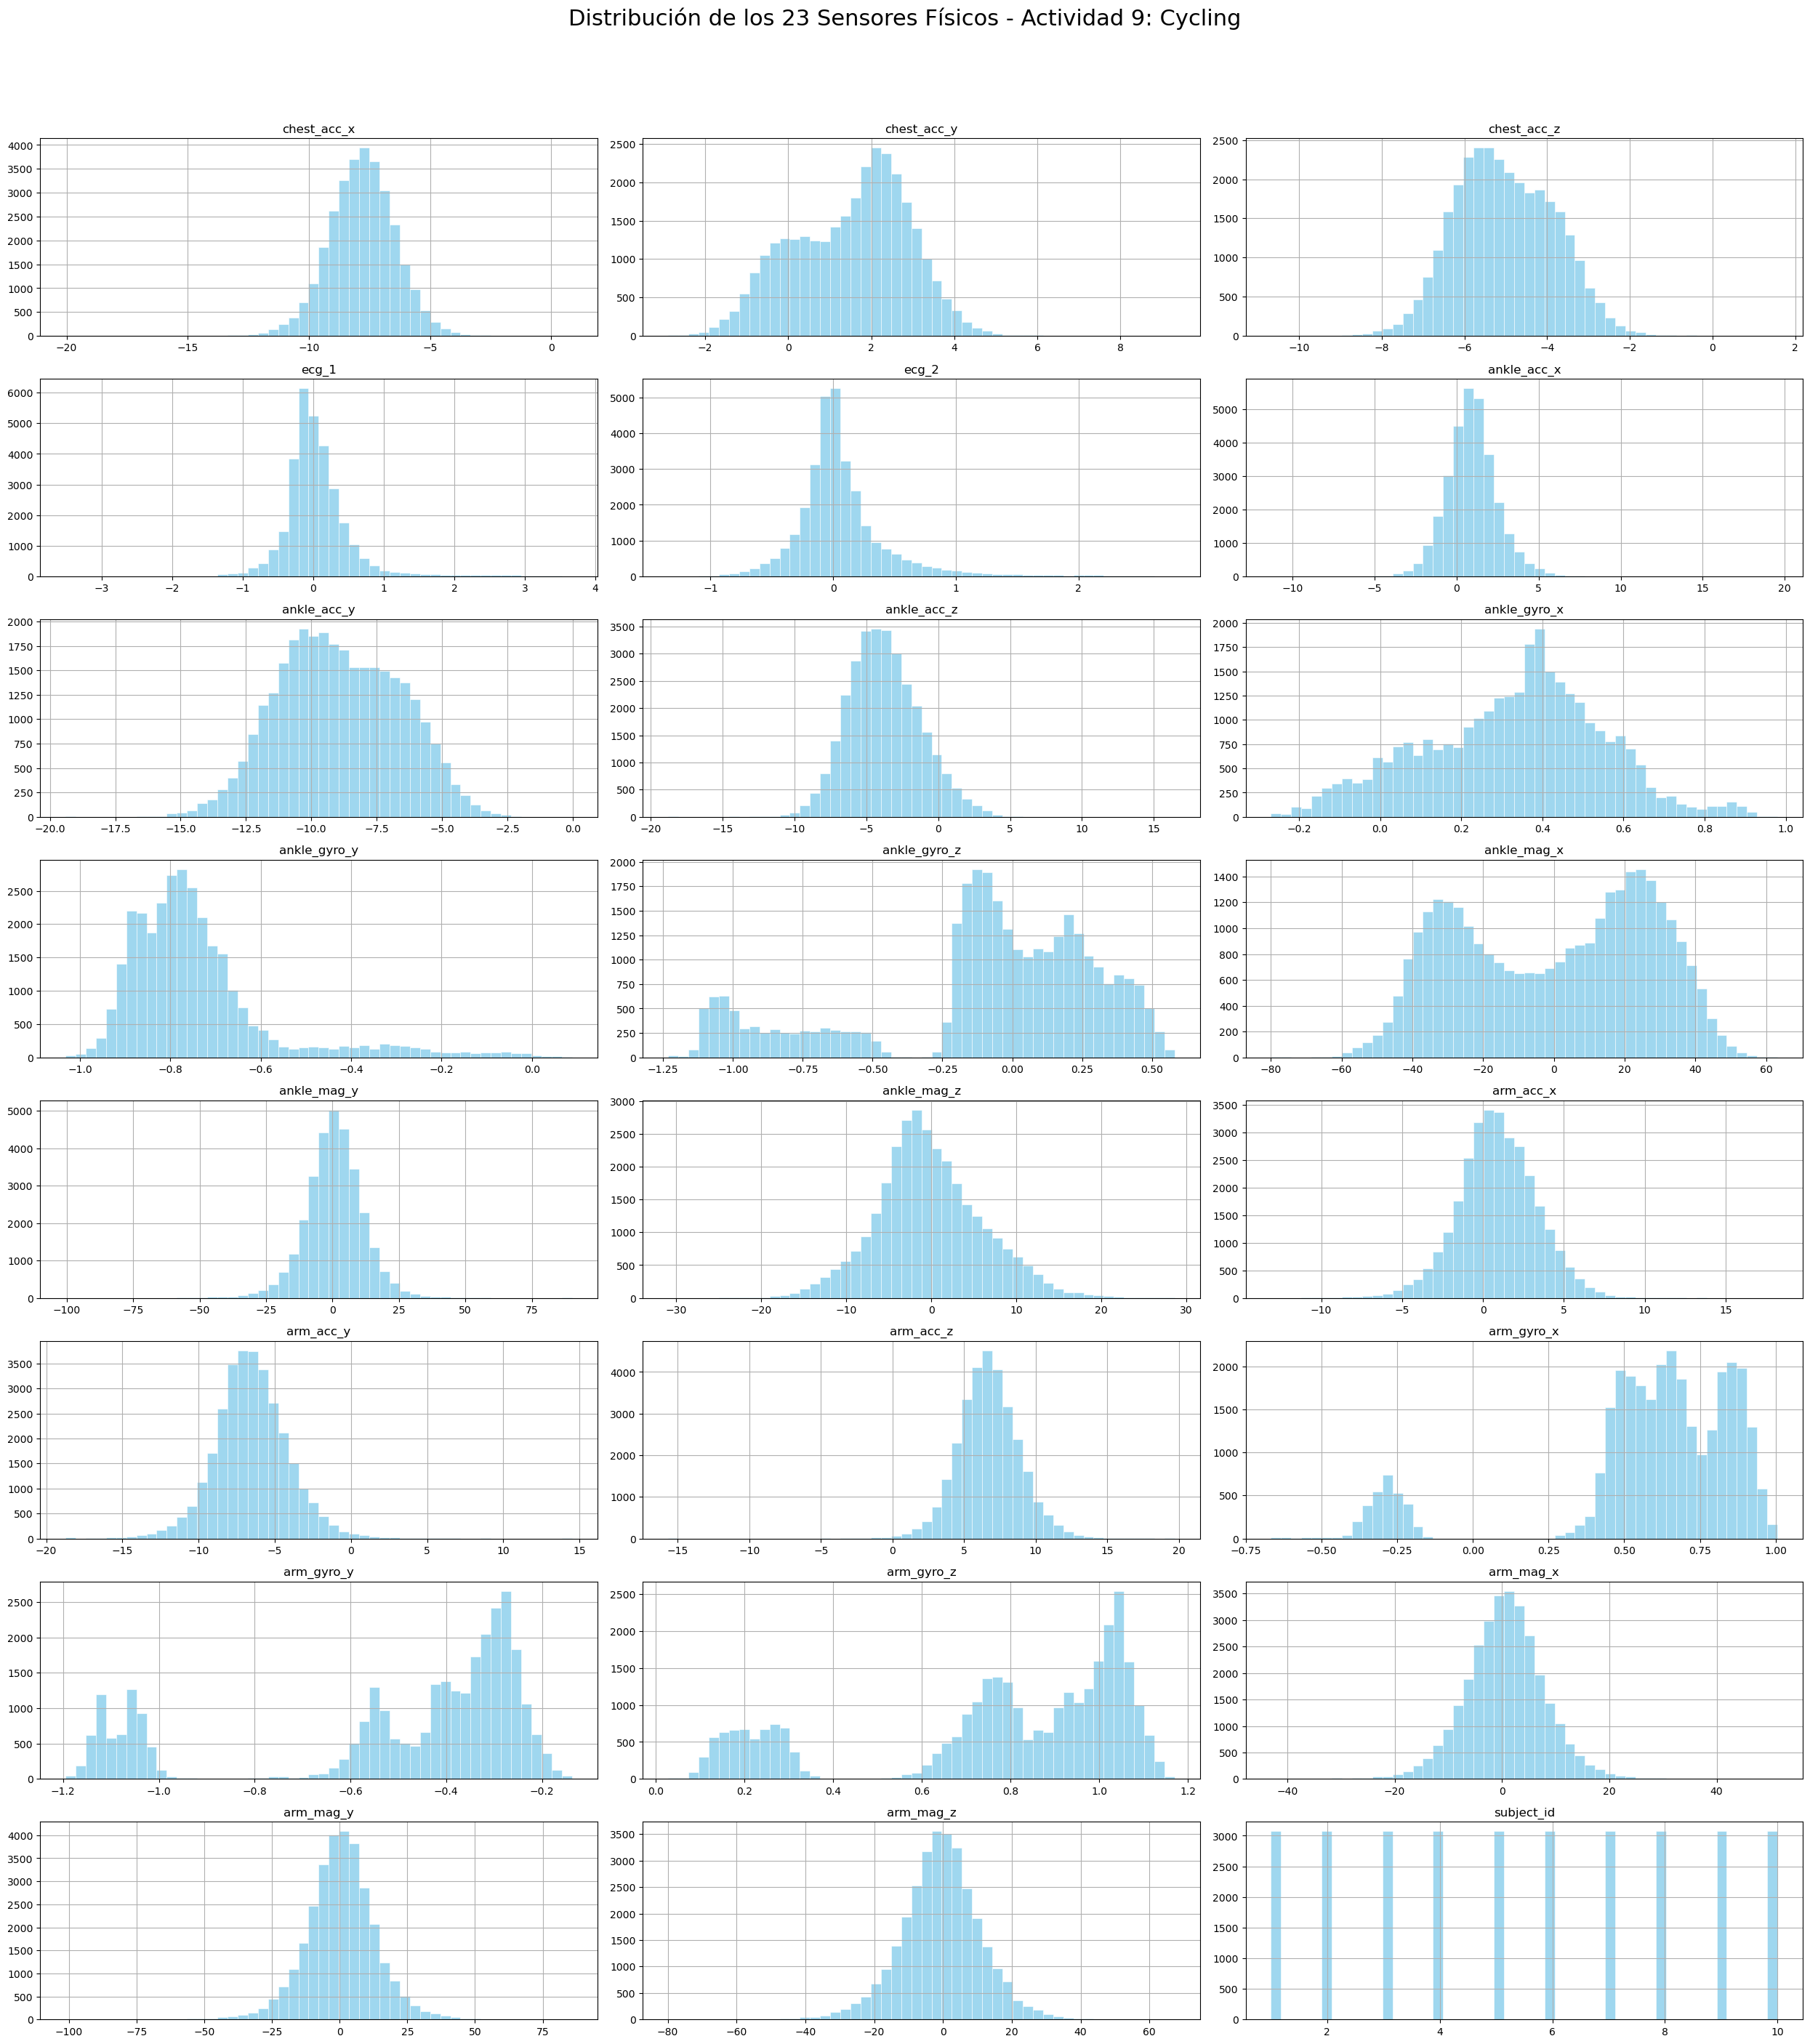

In [7]:


DATASET_SENSORES_ACTIVIDAD.hist(
    bins=50, 
    layout=(15,3),
    figsize=(25, 50), 
    color='skyblue', 
    edgecolor='white', 
    linewidth=0.5,
    alpha=0.8
)

plt.suptitle(f"Distribución de los 23 Sensores Físicos - Actividad {actividad}: {actividades[actividad]}", fontsize=22, y=1.02)
plt.tight_layout()

plt.show

<h1>Outliers</h1>

In [8]:

outliers_info = []

for col in DATASET_SENSORES_ACTIVIDAD.select_dtypes(include="number").columns:
    
    Q1 = DATASET_SENSORES_ACTIVIDAD[col].quantile(0.25)
    Q3 = DATASET_SENSORES_ACTIVIDAD[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    mask_outliers = (DATASET_SENSORES_ACTIVIDAD[col] < lower) | (DATASET_SENSORES_ACTIVIDAD[col] > upper)
    
    total_outliers = mask_outliers.sum()
    percentage = mask_outliers.mean() * 100
    
    outliers_info.append({
        "Sensor": col,
        "Total_Outliers": total_outliers,
        "Porcentaje_Outliers (%)": round(percentage, 2)
    })

outliers_df = pd.DataFrame(outliers_info)

outliers_df

,Sensor,Total_Outliers,Porcentaje_Outliers (%)
0,chest_acc_x,422,1.37
1,chest_acc_y,27,0.09
2,chest_acc_z,78,0.25
3,ecg_1,1817,5.91
4,ecg_2,2956,9.62
5,ankle_acc_x,829,2.70
6,ankle_acc_y,31,0.10
7,ankle_acc_z,328,1.07
8,ankle_gyro_x,10,0.03
9,ankle_gyro_y,2536,8.26


<h1>Gráfica de densidad</h1>

<function matplotlib.pyplot.show(close=None, block=None)>

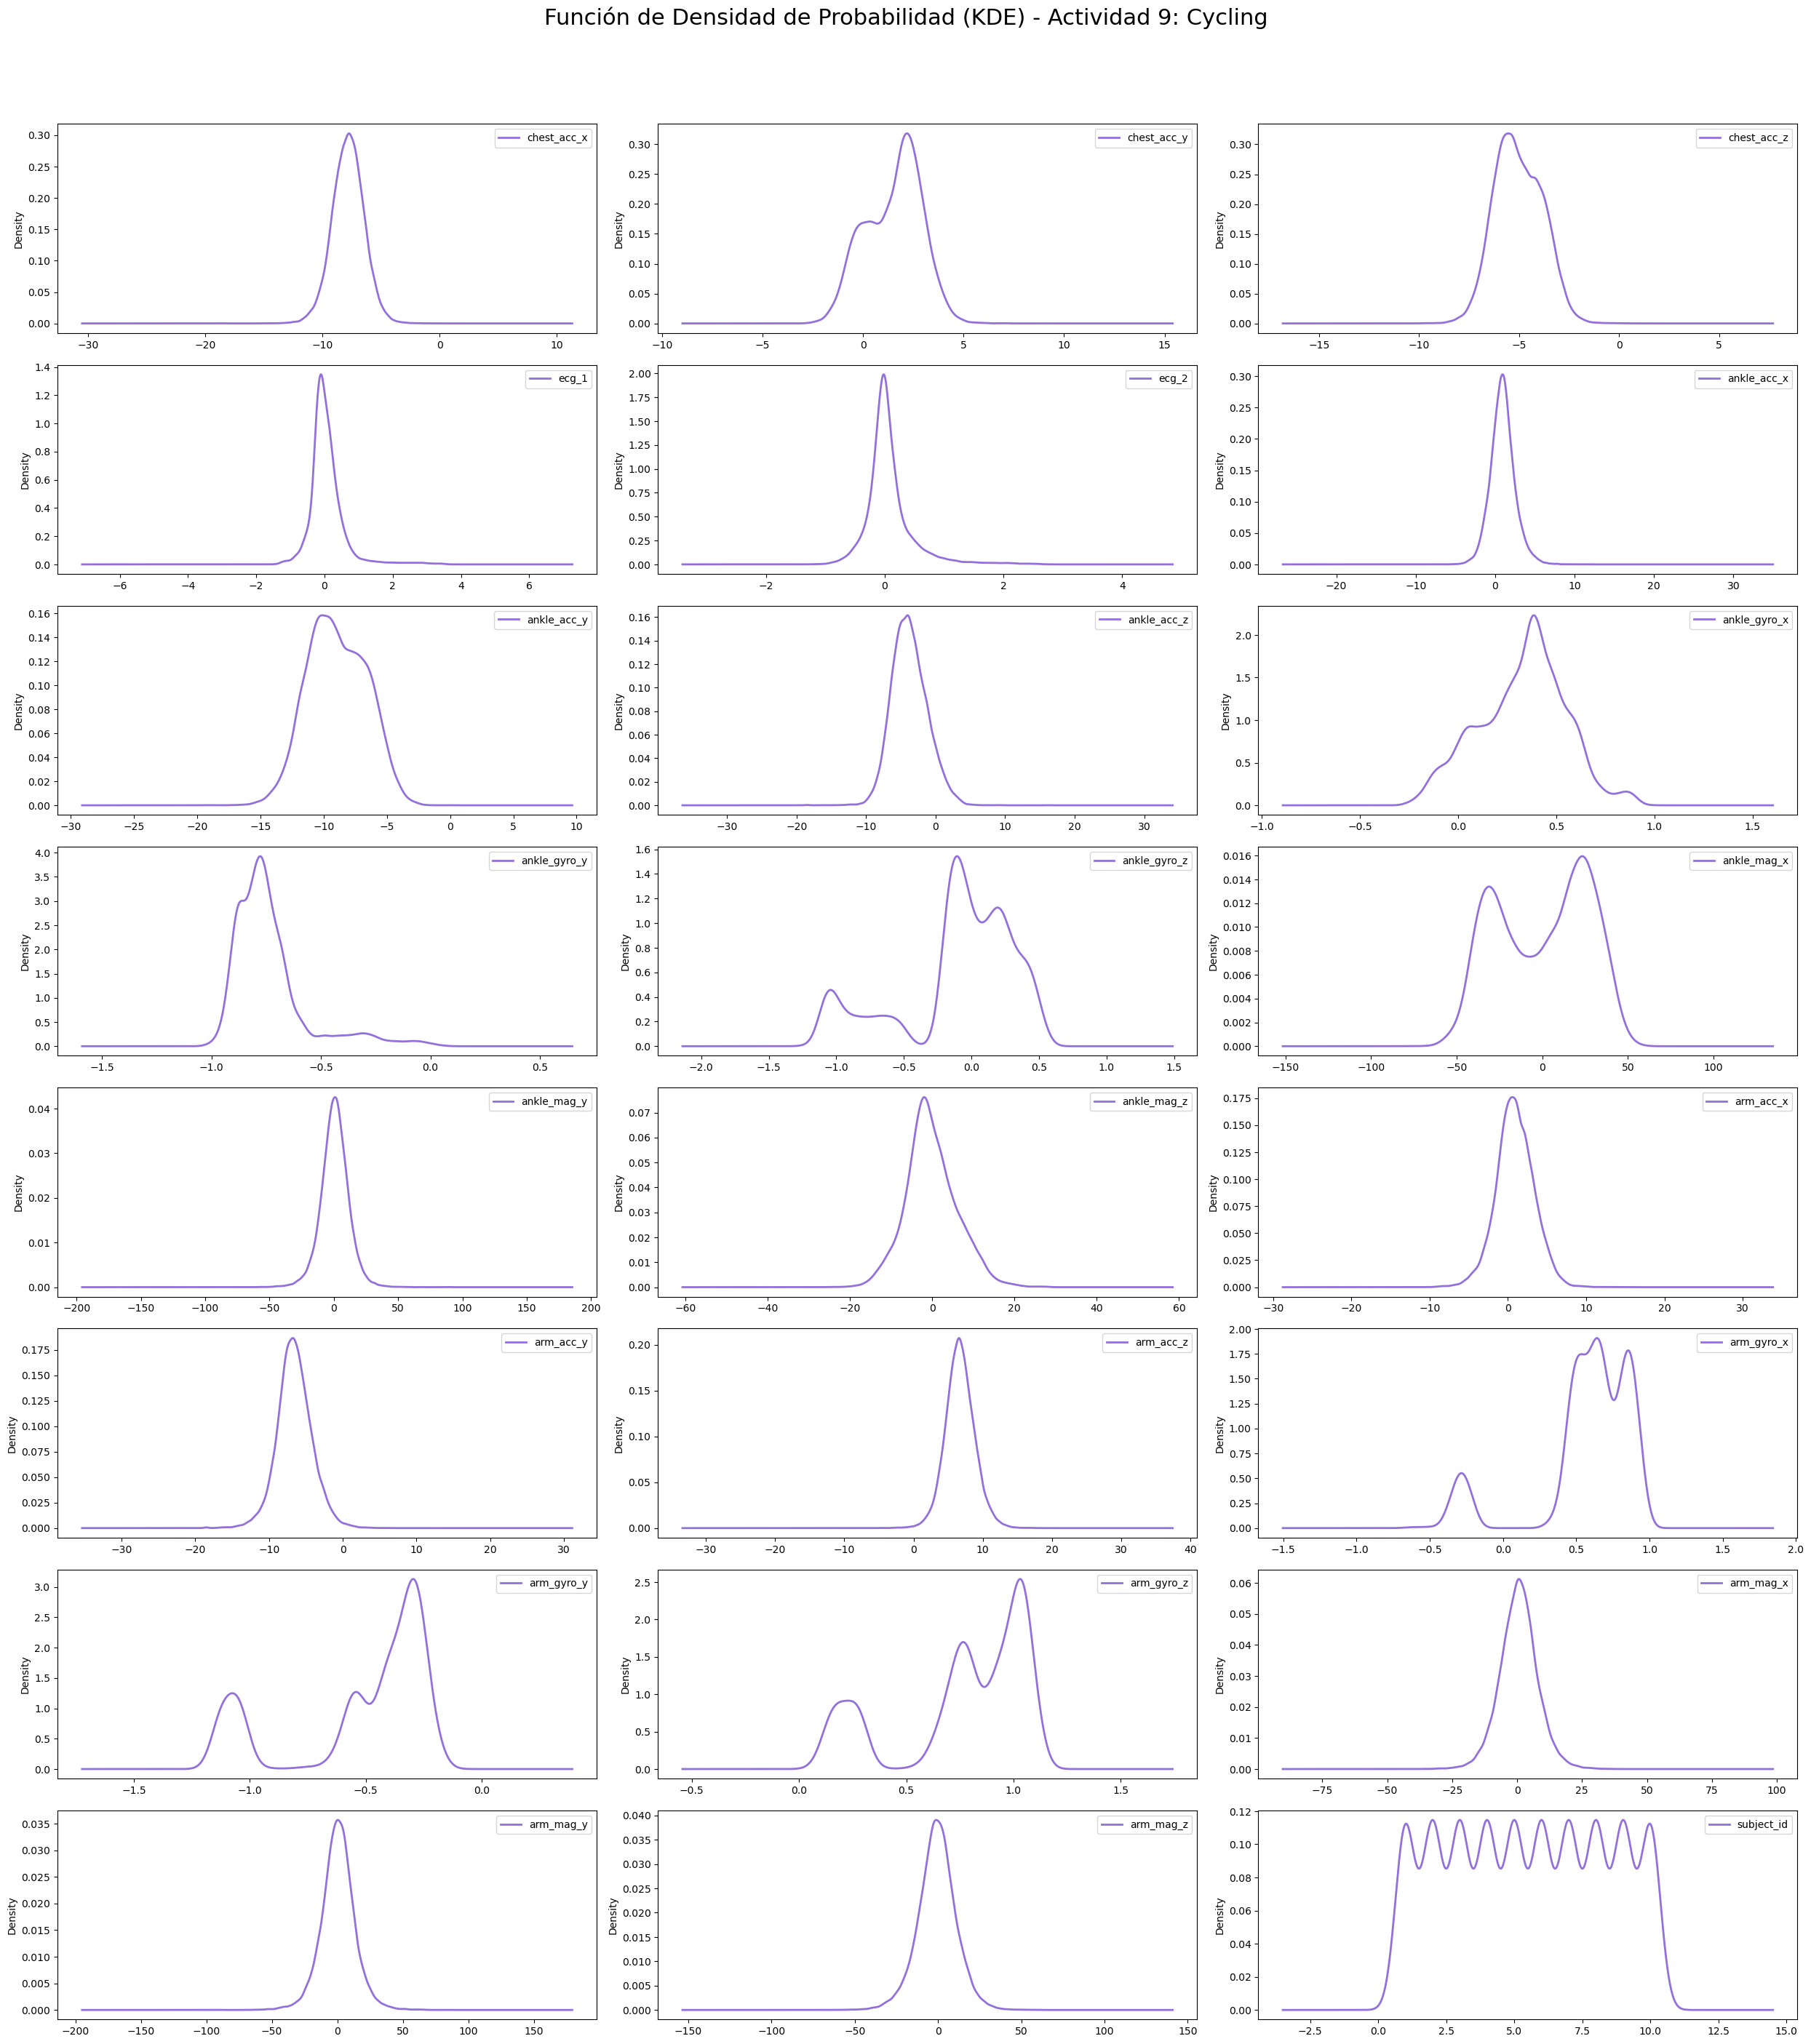

In [9]:
DATASET_SENSORES_ACTIVIDAD.plot(
    kind='density', 
    subplots=True, 
    layout=(15, 3),  
    figsize=(25, 50),
    sharex=False,     
    color='mediumpurple', 
    linewidth=2
)

plt.suptitle(f"Función de Densidad de Probabilidad (KDE) - Actividad {actividad}: {actividades[actividad]}", fontsize=22, y=1.02)
plt.tight_layout()

plt.show

<h1>Gráfica de cajas y bigotes</h1>

<function matplotlib.pyplot.show(close=None, block=None)>

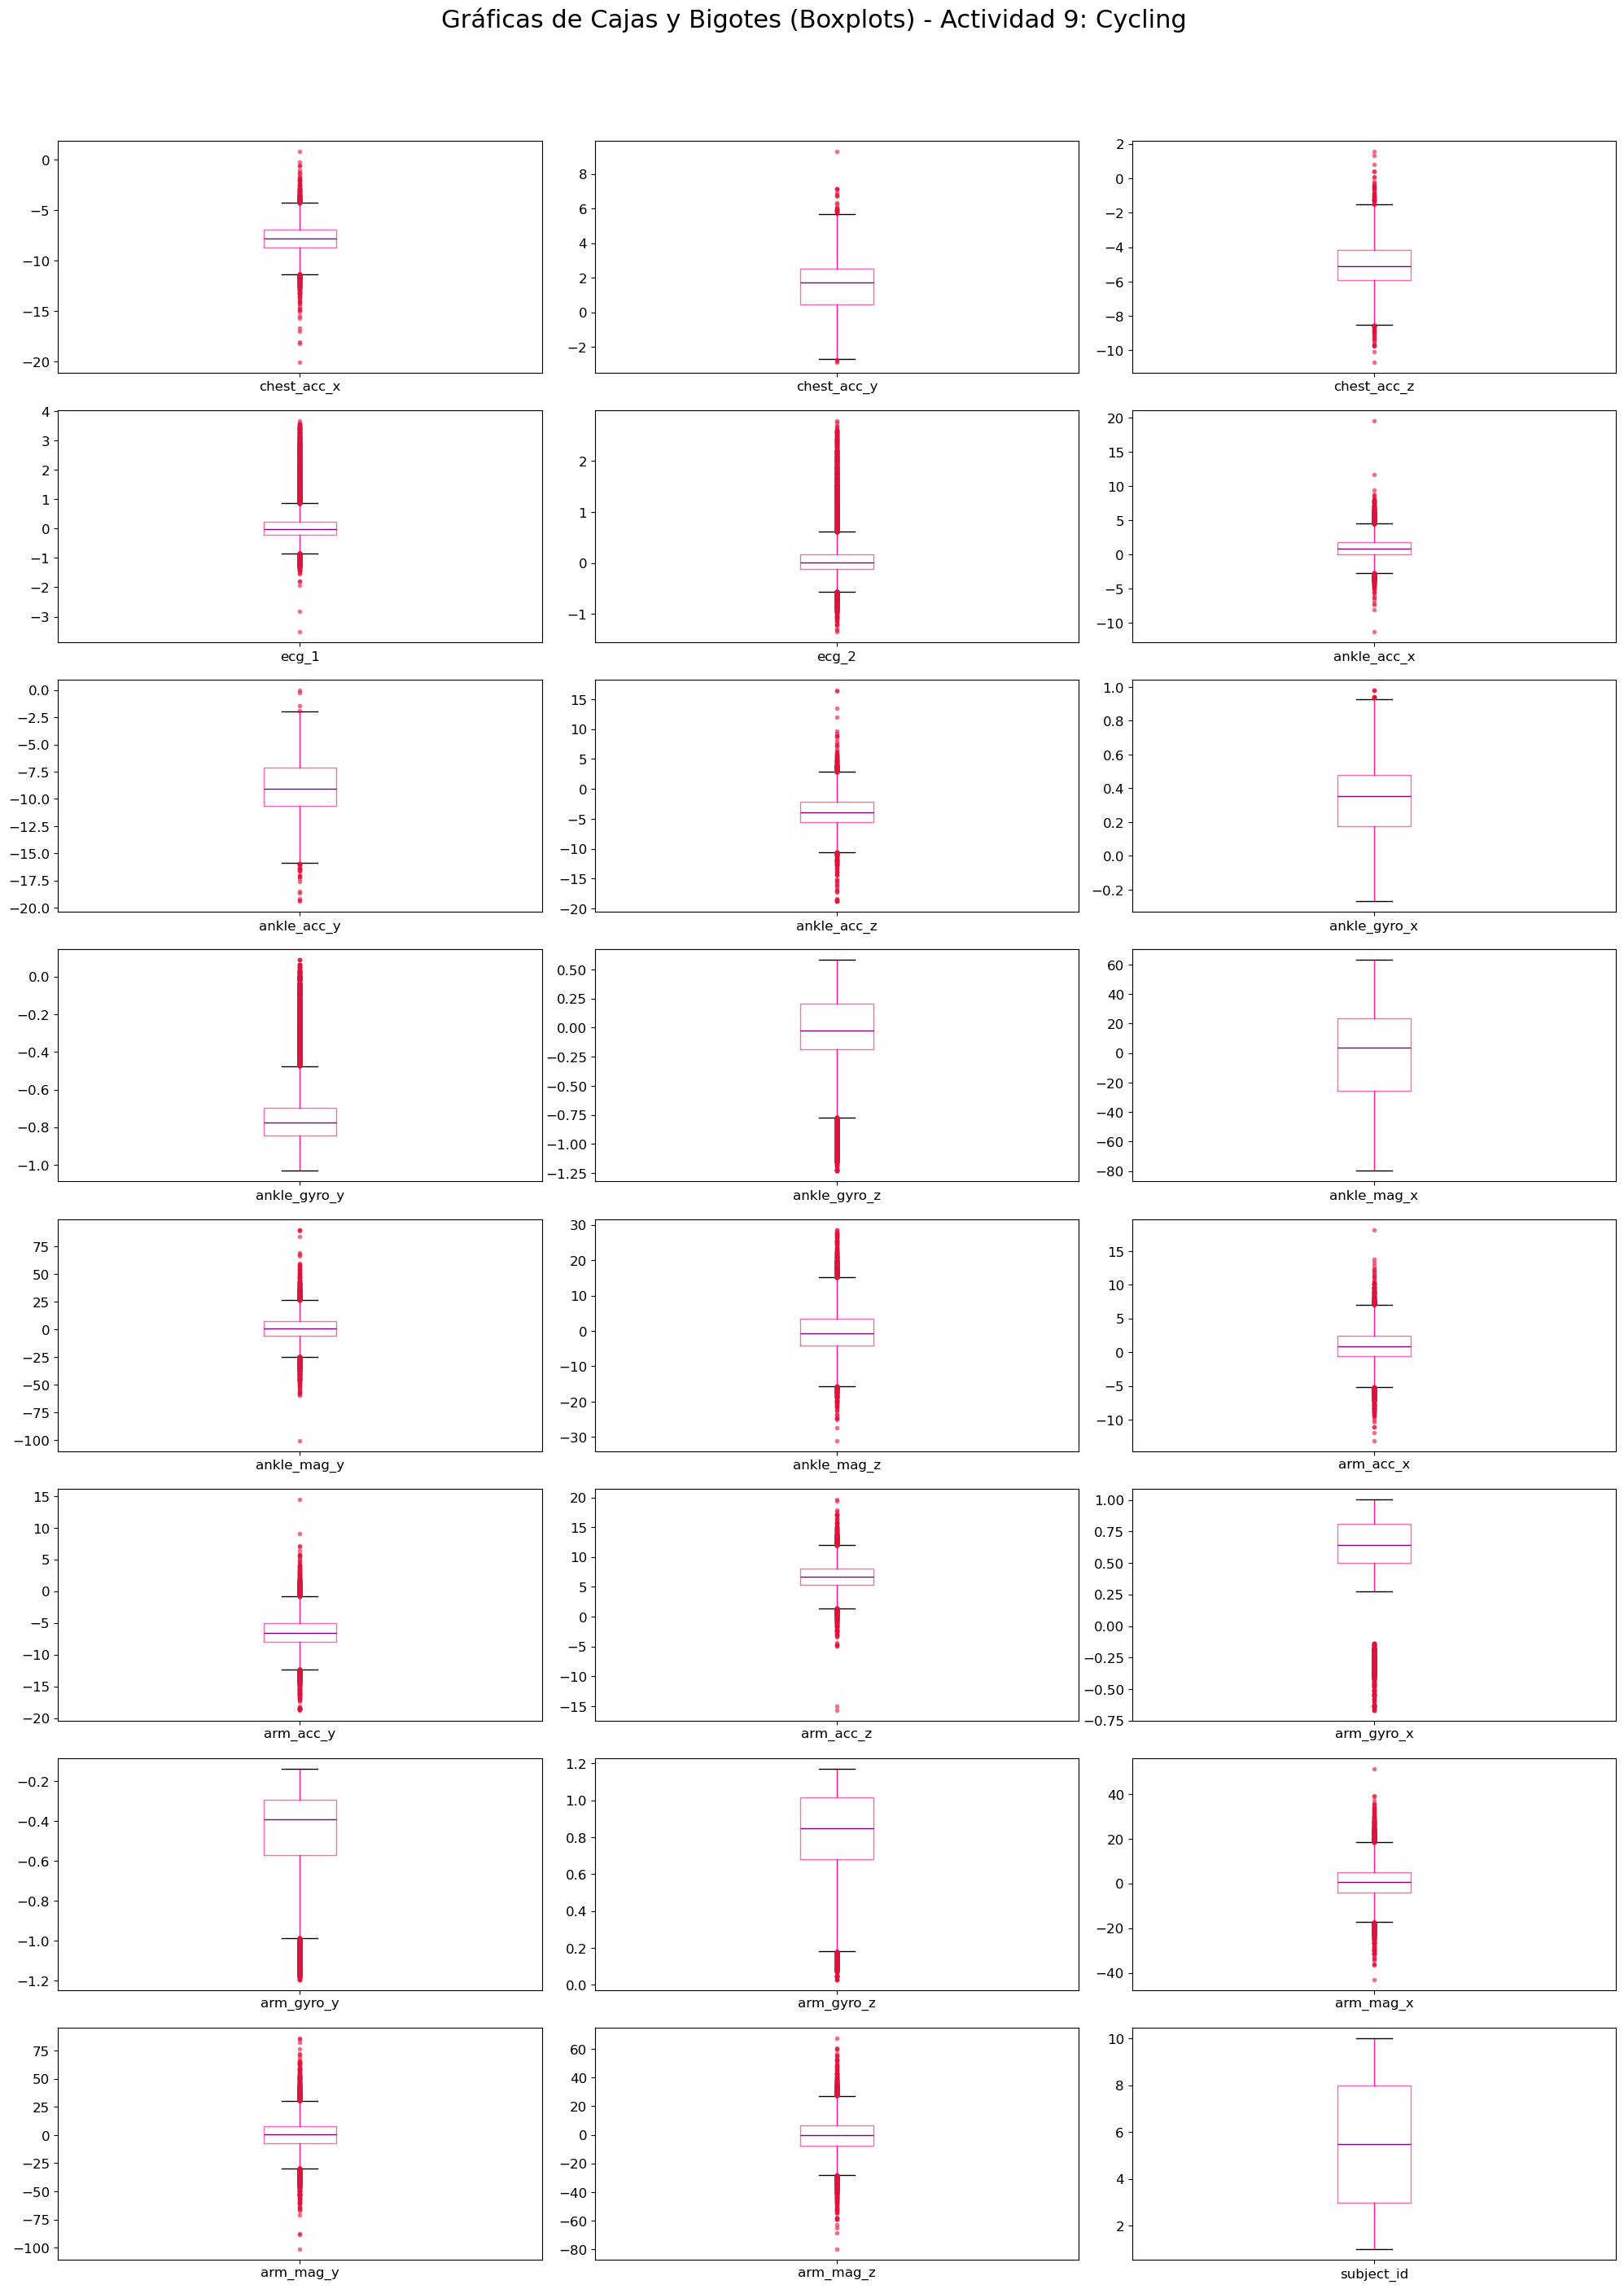

In [10]:
color_props = dict(boxes='hotpink', whiskers='deeppink', medians='purple', caps='black')
puntitos_props = dict(marker='o', markerfacecolor='crimson', markersize=4, alpha=0.6, markeredgecolor='none')

# Dibujamos el mosaico
DATASET_SENSORES_ACTIVIDAD.plot(
    kind='box', 
    subplots=True, 
    layout=(15, 3),  
    figsize=(20, 50), 
    color=color_props,
    flierprops=puntitos_props,
    fontsize=12      
)


plt.suptitle(f'Gráficas de Cajas y Bigotes (Boxplots) - Actividad {actividad}: {actividades[actividad]}', fontsize=22, y=1.02)
plt.tight_layout()

plt.show

<h1>Matriz de correlación</h1>

<function matplotlib.pyplot.show(close=None, block=None)>

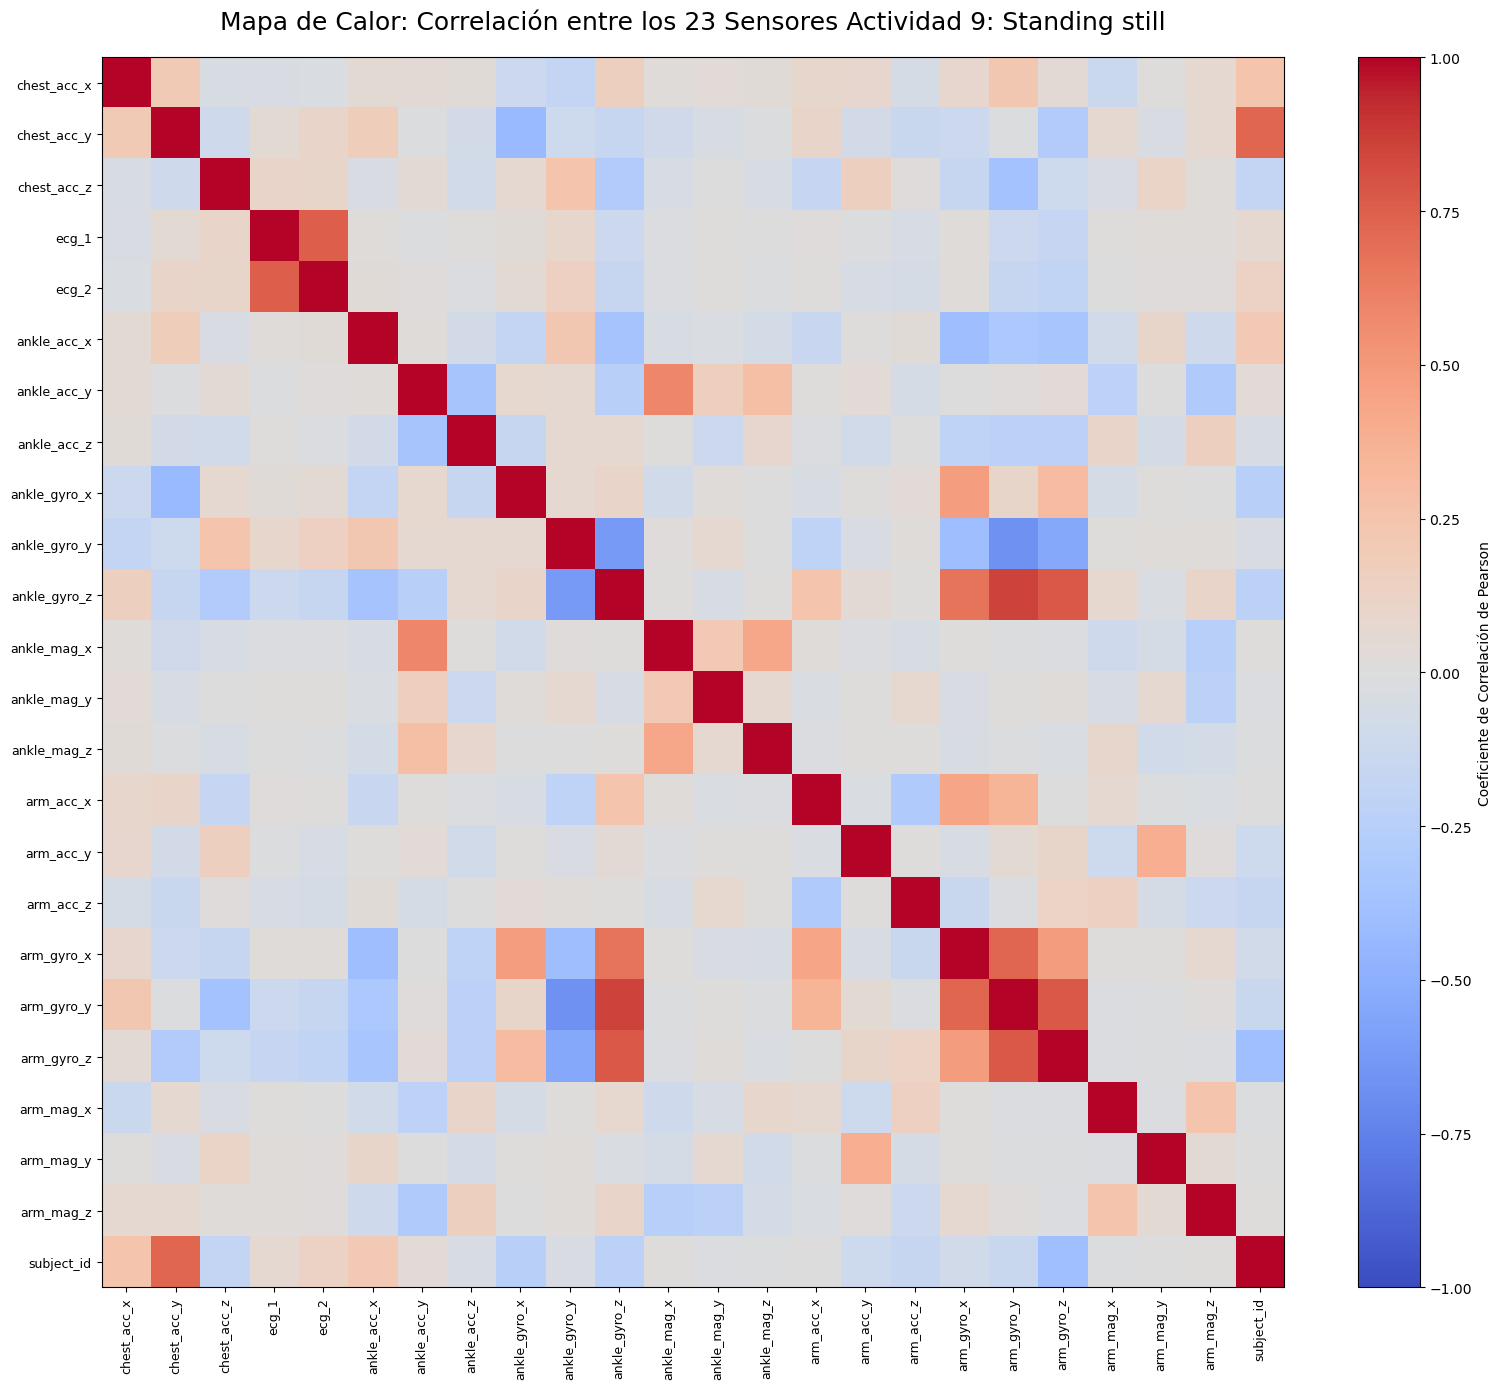

In [11]:
# Calculamos la matriz de correlación de Pearson
matriz_correlacion = DATASET_SENSORES_ACTIVIDAD.corr()

# Dibujamos el Mapa de Calor
plt.figure(figsize=(16, 14))

# Usamos imshow para dibujar la cuadrícula, coolwarm da rojo a los +1 y azul a los -1
imagen = plt.imshow(matriz_correlacion, cmap='coolwarm', vmin=-1, vmax=1, aspect='auto')

# Agregamos la barra de colores al lado
plt.colorbar(imagen, label='Coeficiente de Correlación de Pearson')
plt.title(f'Mapa de Calor: Correlación entre los 23 Sensores Actividad {actividad}: {actividades[1]}', fontsize=18, pad=20)

# Ponemos los nombres de las 45 columnas en los bordes
posiciones = np.arange(len(DATASET_SENSORES_ACTIVIDAD.columns))
plt.xticks(posiciones, DATASET_SENSORES_ACTIVIDAD.columns, rotation=90, fontsize=9)
plt.yticks(posiciones, DATASET_SENSORES_ACTIVIDAD.columns, fontsize=9)

plt.grid(False) 
plt.tight_layout()

plt.show

<h1>Matriz de dispersión</h1>

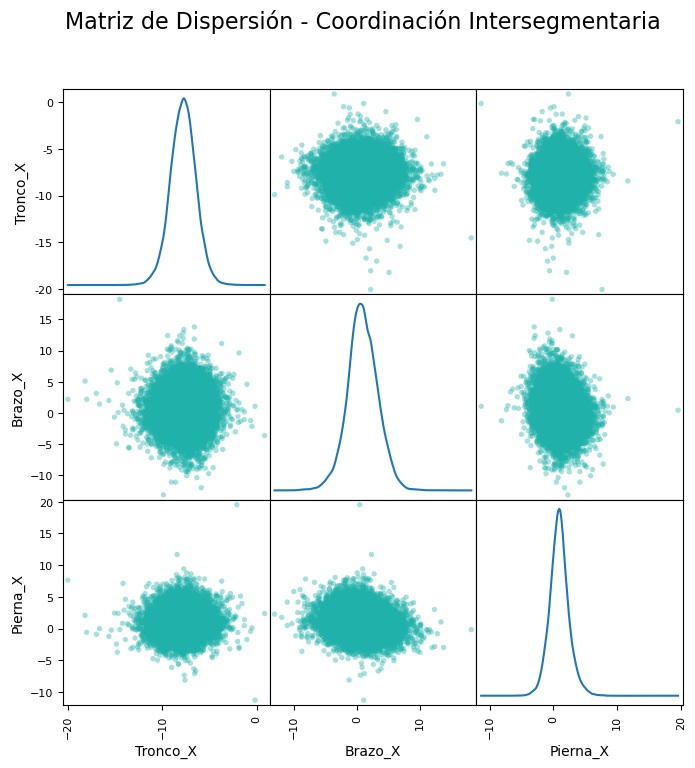

In [12]:
# Selección estratégica: un eje X por segmento corporal
sensores_estrategicos = [
    "chest_acc_x",   # Tronco
    "arm_acc_x",     # Brazo derecho
    "ankle_acc_x"    # Pierna
]

datos_scatter = DATASET_SENSORES_ACTIVIDAD[sensores_estrategicos].copy()


datos_scatter.columns = [
    "Tronco_X",
    "Brazo_X",
    "Pierna_X"
]

pd.plotting.scatter_matrix(
    datos_scatter,
    alpha=0.4,
    figsize=(8, 8),
    diagonal='kde',
    color='lightseagreen',
    marker='o',
    s=15
)

plt.suptitle(
    'Matriz de Dispersión - Coordinación Intersegmentaria',
    fontsize=16
)

plt.show()

<h1>Matriz de dispersión por sujeto</h1>

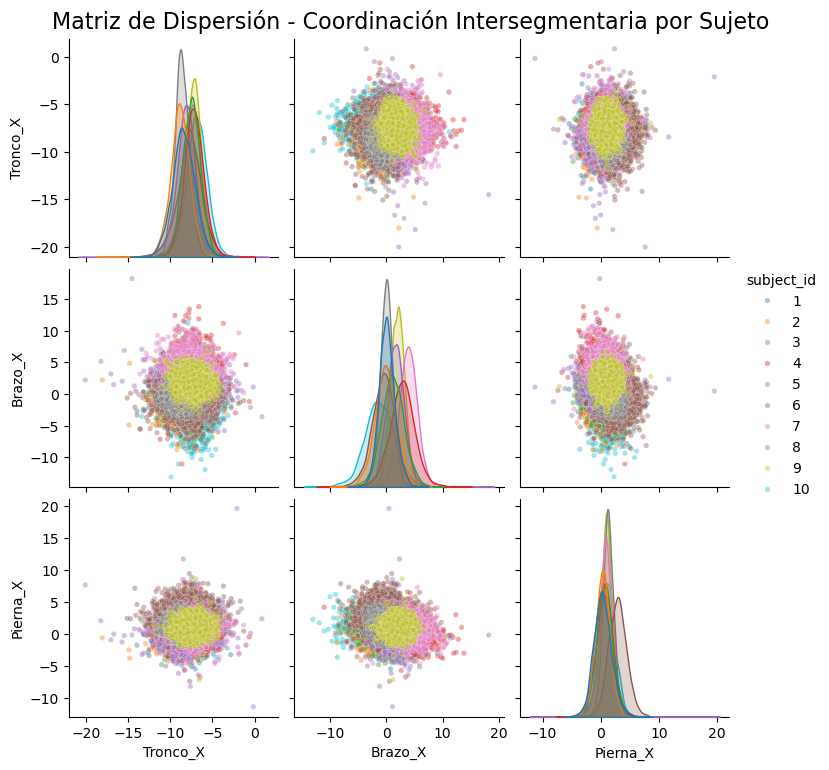

In [13]:
# Selección estratégica
sensores_estrategicos = [
    "chest_acc_x",   # Tronco
    "arm_acc_x",     # Brazo derecho
    "ankle_acc_x"    # Pierna
]

datos_scatter = DATASET_SENSORES_ACTIVIDAD[sensores_estrategicos + ["subject_id"]].copy()

datos_scatter.columns = [
    "Tronco_X",
    "Brazo_X",
    "Pierna_X",
    "subject_id"
]

# Convertir a categoría (importante para que seaborn lo trate como grupo)
datos_scatter["subject_id"] = datos_scatter["subject_id"].astype("category")

# Pairplot con color por sujeto
sns.pairplot(
    datos_scatter,
    vars=["Tronco_X", "Brazo_X", "Pierna_X"],
    hue="subject_id",
    diag_kind="kde",
    plot_kws={"alpha": 0.4, "s": 15}
)

plt.suptitle(
    'Matriz de Dispersión - Coordinación Intersegmentaria por Sujeto',
    y=1.02,
    fontsize=16
)

plt.show()